# 🍷 Wine Quality Prediction
### Comparing 15 ML & Deep Learning Models on WineQT Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

## 1. Load & Explore Data

In [2]:
df = pd.read_csv('WineQT.csv')
df = df.drop('Id', axis=1)
print('Shape:', df.shape)
df.head()

Shape: (1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## 2. EDA

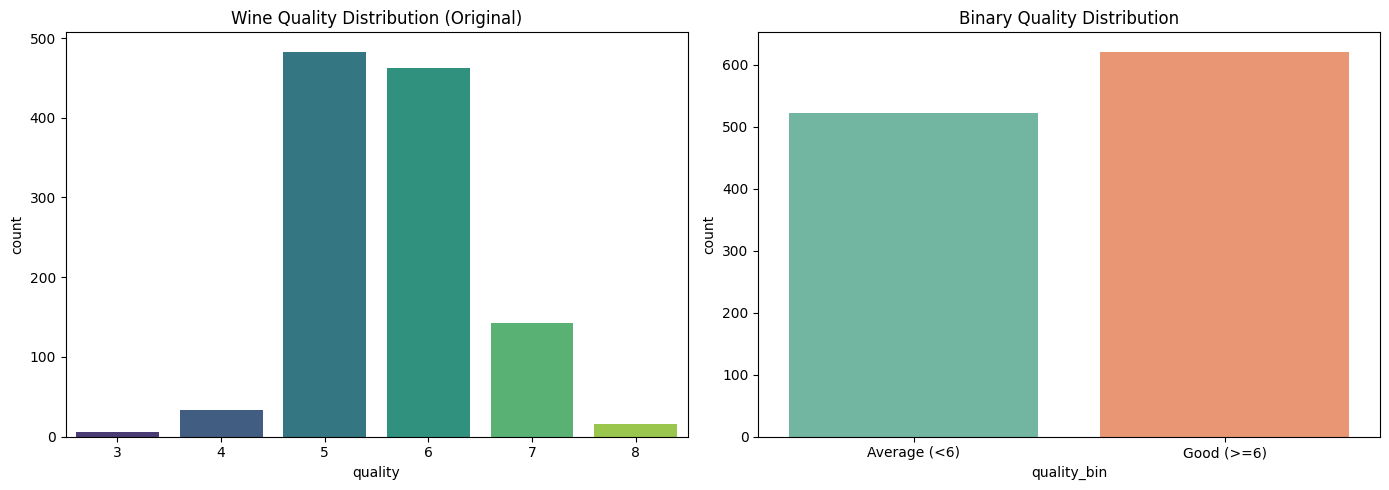

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='quality', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Wine Quality Distribution (Original)')
df_temp = df.copy()
df_temp['quality_bin'] = (df_temp['quality'] >= 6).map({True: 'Good (>=6)', False: 'Average (<6)'})
sns.countplot(x='quality_bin', data=df_temp, palette='Set2', ax=axes[1])
axes[1].set_title('Binary Quality Distribution')
plt.tight_layout()
plt.show()

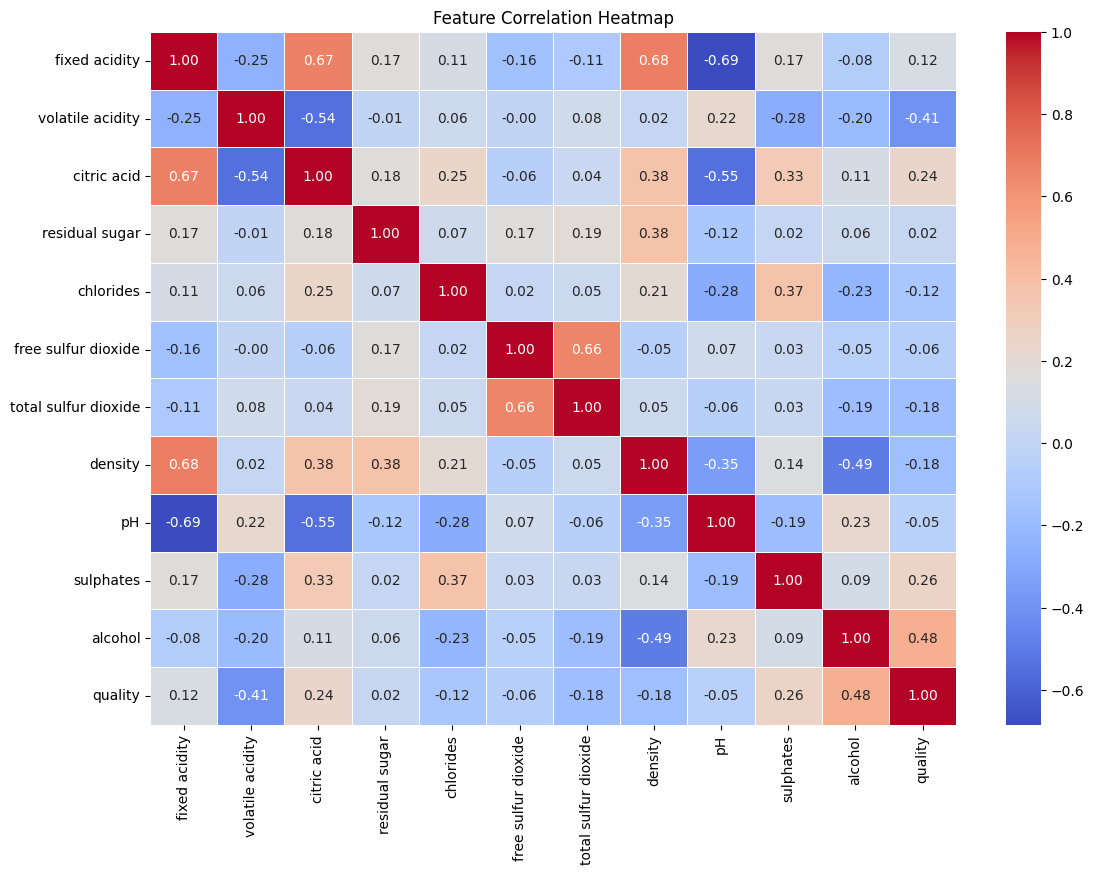

In [6]:
plt.figure(figsize=(13, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 3. Preprocessing

In [7]:
df['quality'] = (df['quality'] >= 6).astype(int)
print('Class Distribution:\n', df['quality'].value_counts())
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Class Distribution:
 quality
1    621
0    522
Name: count, dtype: int64
Train: (914, 11) | Test: (229, 11)


## 4. Train & Compare All 15 Models

In [8]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=200, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Poly)'          : SVC(kernel='poly', degree=3, probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'MLP Neural Network'  : MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42),
    'MLP Deep'            : MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32), max_iter=500, random_state=42),
    'LDA'                 : LinearDiscriminantAnalysis(),
    'QDA'                 : QuadraticDiscriminantAnalysis(),
    'Bagging'             : BaggingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, m in models.items():
    m.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_sc))
    results[name] = acc
    print(f'{name:30s}: {acc*100:.2f}%')

best_name = max(results, key=results.get)
print(f'\n🏆 Best: {best_name} — {results[best_name]*100:.2f}%')

Logistic Regression           : 76.86%
Random Forest                 : 75.98%
Gradient Boosting             : 77.29%
AdaBoost                      : 75.55%
Extra Trees                   : 78.60%
SVM (RBF)                     : 76.42%
SVM (Poly)                    : 75.11%
KNN                           : 72.49%
Decision Tree                 : 68.12%
Naive Bayes                   : 74.67%
MLP Neural Network            : 78.17%
MLP Deep                      : 75.55%
LDA                           : 75.98%
QDA                           : 70.31%
Bagging                       : 75.11%

🏆 Best: Extra Trees — 78.60%


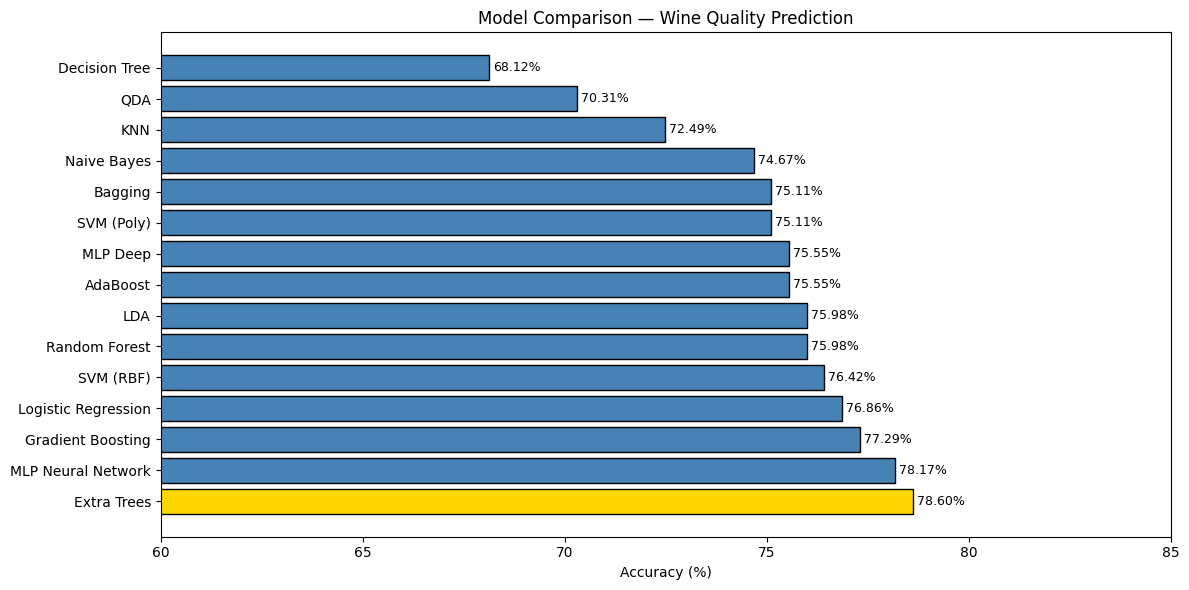

In [9]:
res_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy']).sort_values('Accuracy', ascending=False)
plt.figure(figsize=(12, 6))
colors = ['gold' if m == best_name else 'steelblue' for m in res_df['Model']]
bars = plt.barh(res_df['Model'], res_df['Accuracy']*100, color=colors, edgecolor='black')
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison — Wine Quality Prediction')
plt.xlim(60, 85)
for bar, val in zip(bars, res_df['Accuracy']):
    plt.text(val*100+0.1, bar.get_y()+bar.get_height()/2, f'{val*100:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning — Extra Trees (Best Model)

In [10]:
param_grid = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}
gs = GridSearchCV(ExtraTreesClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train_sc, y_train)
best_model = gs.best_estimator_
best_acc   = accuracy_score(y_test, best_model.predict(X_test_sc))
print(f'Best Params : {gs.best_params_}')
print(f'Final Accuracy: {best_acc*100:.2f}%')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Final Accuracy: 78.60%


In [11]:
print(classification_report(y_test, best_model.predict(X_test_sc), target_names=['Average','Good']))

              precision    recall  f1-score   support

     Average       0.76      0.75      0.76       102
        Good       0.80      0.81      0.81       127

    accuracy                           0.79       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.79      0.79      0.79       229



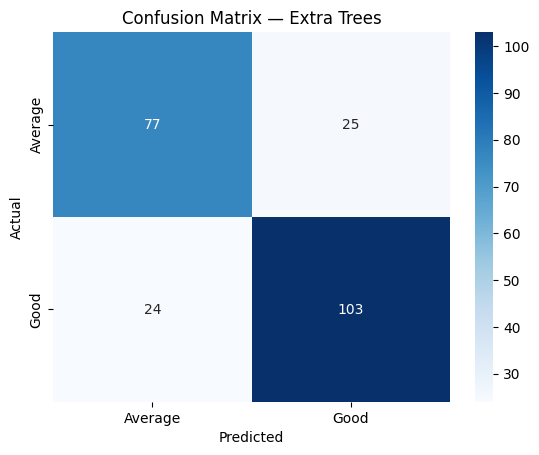

In [12]:
cm = confusion_matrix(y_test, best_model.predict(X_test_sc))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Average','Good'], yticklabels=['Average','Good'])
plt.title('Confusion Matrix — Extra Trees')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

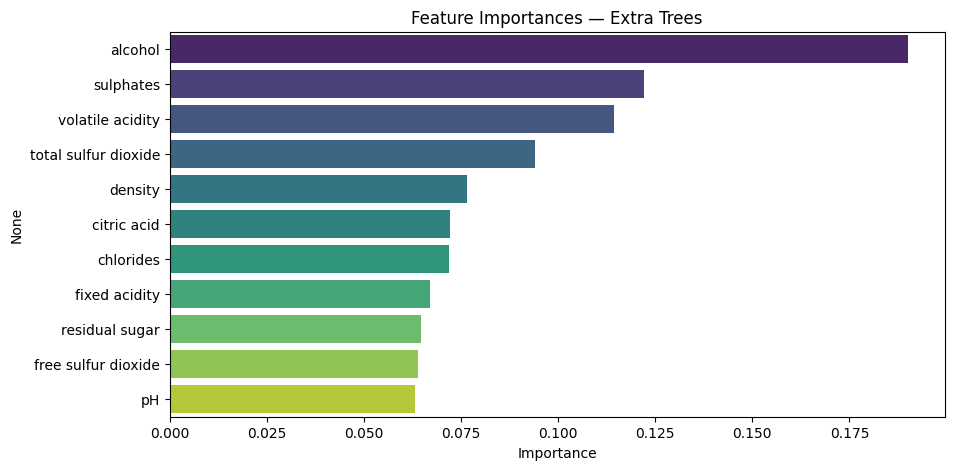

In [13]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importances — Extra Trees')
plt.xlabel('Importance')
plt.show()

## 6. Save Model Artifacts

In [14]:
columns = list(X.columns)
pickle.dump(columns,    open('columns.pkl', 'wb'))
pickle.dump(scaler,     open('scaler.pkl',  'wb'))
pickle.dump(best_model, open('lg_wine.pkl', 'wb'))
print('All artifacts saved: columns.pkl, scaler.pkl, lg_wine.pkl')

All artifacts saved: columns.pkl, scaler.pkl, lg_wine.pkl
